<a href="https://colab.research.google.com/github/viktoriia-yarmolchuk/portfolio-projects/blob/main/analysis_of_ab_testing_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

## **Connecting to a database in Goggle BigQuery**

In [ ]:
auth.authenticate_user()

In [ ]:
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
query = """
with session_info as(
 select
     s.date,
     s.ga_session_id,
     p.country,
     p.device,
     p.continent,
     p.channel,
     a.test,
     a.test_group
 from `DA.ab_test` a
 join `DA.session` s on a.ga_session_id = s.ga_session_id
 join `DA.session_params` p on p.ga_session_id = a.ga_session_id
),
sessions_with_orders as (
 select
     s.date,
     s.country,
     s.device,
     s.continent,
     s.channel,
     s.test,
     s.test_group,
     count(distinct o.ga_session_id) as value
 from `DA.order` o
 join session_info s on o.ga_session_id = s.ga_session_id
 group by all
),
events as(
 select
     s.date,
     s.country,
     s.device,
     s.continent,
     s.channel,
     s.test,
     s.test_group,
     count(distinct e.ga_session_id) as value,
     e.event_name
 from `DA.event_params` e
 join session_info s on e.ga_session_id = s.ga_session_id
 group by all
),
session as (
 select
     s.date,
     s.country,
     s.device,
     s.continent,
     s.channel,
     s.test,
     s.test_group,
     count(distinct s.ga_session_id) as value
 from session_info s
 group by all
),
account as(
 select
     s.date,
     s.country,
     s.device,
     s.continent,
     s.channel,
     s.test,
     s.test_group,
     count(distinct a.ga_session_id) as value
 from `DA.account_session` a
 join session_info s on a.ga_session_id = s.ga_session_id
 group by all
)
select *,
'session with orders' as event_name
from sessions_with_orders
union all
select *
from events
union all
select *,
'session' as event_name
from session
union all
select *,
'new account' as event_name
from account
"""

In [ ]:
query_job = client.query(query)
results = query_job.result()

df = results.to_dataframe()

In [ ]:
df.head()

,date,country,device,continent,channel,test,test_group,value,event_name
0,2020-11-01,Lithuania,mobile,Europe,Organic Search,2,2,1,new account
1,2020-11-01,El Salvador,desktop,Americas,Social Search,2,1,1,new account
2,2020-11-01,Slovakia,mobile,Europe,Paid Search,2,2,1,new account
3,2020-11-01,Lithuania,desktop,Europe,Paid Search,2,2,1,new account
4,2020-11-02,North Macedonia,desktop,Europe,Direct,2,1,1,new account


## **Creating an A/B testing analyzer**

### What is this tool for?

This script automates the calculation of statistical significance for A/B tests.

Instead of manually inserting numbers into online calculators, the tool itself goes through all metrics and segments and generates a ready-made file with results for further visualization.

The final table contains the following key columns:

- **conversion_rate_control** — control group conversion
- **conversion_rate_test** — test group conversion
- **metric_change** — relative change between groups (+0.05 = +5%)
- **p_value** — probability that the difference is random
- **significant** — `True` if the difference is real, `False` if it is random

> Significance level: **α = 0.05**  
> If p_value < 0.05 → the result is considered statistically significant

### Statistical method

**Two-sample z-test for proportions** is used
(`proportions_ztest` from the library `statsmodels`).

It compares two conversions and tests the null hypothesis:

> **H₀:** there is no difference between control and test  
> **H₁:** the difference exists

If p_value < α → reject H₀ → the change has a real effect.

### A/B testing analyzer

In [ ]:
class ABTestAnalyzer:
    """
    A/B test analysis tool:
      - groups data into any segments
      - performs conversions for control and test
      - performs two-sample z-test for proportions
      - returns the final dataframe and saves it to CSV

    Parameters
    ----------------------
    df              : pd.DataFrame  — input dataset
    metrics         : dict          — {metric name: {numerator, denominator}}
    segment_configs : list[dict]    — [{name, columns}], [] = total
    alpha           : float         — significance level (default 0.05)
    control_group   : int           — default 1
    test_group      : int           — default 2

    Using
    ------------
    analyzer = ABTestAnalyzer(df, METRICS, SEGMENTS)
    results  = analyzer.run(output_path='results.csv')
    """

    def __init__(
        self,
        df:              pd.DataFrame,
        metrics:         dict,
        segment_configs: list,
        alpha:           float = 0.05,
        control_group:   int   = 1,
        test_group: int   = 2,
    ):
        self.df              = df.copy()
        self.metrics         = metrics
        self.segment_configs = segment_configs
        self.alpha           = alpha
        self.control_group   = control_group
        self.test_group      = test_group

        self._all_events = list({
            event
            for cfg in metrics.values()
            for event in (cfg['numerator'], cfg['denominator'])
        })

    # PUBLIC METHOD

    def run(self, output_path: str = 'ab_test_results.csv') -> pd.DataFrame:
        """
        Runs a full calculation and saves the result in CSV

        """
        results = []

        for seg_cfg in self.segment_configs:
            seg_rows = self._process_segment(seg_cfg)
            results.extend(seg_rows)

        df_result = self._build_dataframe(results)
        df_result.to_csv(output_path, index=False)

        return df_result

    # PRIVATE METHODS

    def _process_segment(self, seg_cfg: dict) -> list:
        """
        Processes one segment - returns a list of result rows
        """
        seg_name = seg_cfg['name']
        seg_cols = seg_cfg['columns']

        group_cols = list(dict.fromkeys(['test'] + seg_cols))

        pivot = self._build_pivot(group_cols)

        ctrl  = pivot[pivot['test_group'] == self.control_group]
        treat = pivot[pivot['test_group'] == self.test_group]

        # Unique combinations of segment values
        combo_cols   = [c for c in group_cols if c != 'test_group']
        unique_combos = pivot[combo_cols].drop_duplicates().reset_index(drop=True)

        rows = []
        for _, combo in unique_combos.iterrows():
            mask_ctrl  = self._combo_mask(ctrl,  combo, combo_cols)
            mask_treat = self._combo_mask(treat, combo, combo_cols)

            for metric_name, metric_cfg in self.metrics.items():
                row = self._calculate_row(
                    seg_name    = seg_name,
                    combo       = combo,
                    combo_cols  = combo_cols,
                    metric_name = metric_name,
                    metric_cfg  = metric_cfg,
                    ctrl_rows   = ctrl[mask_ctrl],
                    treat_rows  = treat[mask_treat],
                )
                if row:
                    rows.append(row)

        return rows

    def _build_pivot(self, group_cols: list) -> pd.DataFrame:
        """
        Builds a pivot table: group_cols + test_group → event sums
        """
        filtered = self.df[self.df['event_name'].isin(self._all_events)]

        agg_cols = group_cols + ['test_group', 'event_name']
        grouped  = filtered.groupby(agg_cols, as_index=False)['value'].sum()

        pivot = grouped.pivot_table(
            index   = group_cols + ['test_group'],
            columns = 'event_name',
            values  = 'value',
            aggfunc = 'sum',
        ).reset_index()
        pivot.columns.name = None

        return pivot

    @staticmethod
    def _combo_mask(df: pd.DataFrame, combo: pd.Series, cols: list) -> pd.Series:
        """
        Filtering mask by combination of segment column values.
        """
        mask = pd.Series(True, index=df.index)
        for col in cols:
            mask &= df[col] == combo[col]
        return mask

    def _calculate_row(
        self,
        seg_name:    str,
        combo:       pd.Series,
        combo_cols:  list,
        metric_name: str,
        metric_cfg:  dict,
        ctrl_rows:   pd.DataFrame,
        treat_rows:  pd.DataFrame,
    ) -> dict | None:
        """Calculates one row of results for metric + segment combination."""
        num_event = metric_cfg['numerator']
        den_event = metric_cfg['denominator']

        # Checking for events in data
        if num_event not in ctrl_rows.columns or den_event not in ctrl_rows.columns:
            return None

        n_ctrl  = int(ctrl_rows[num_event].sum())  if len(ctrl_rows)  else 0
        d_ctrl  = int(ctrl_rows[den_event].sum())  if len(ctrl_rows)  else 0
        n_treat = int(treat_rows[num_event].sum()) if len(treat_rows) else 0
        d_treat = int(treat_rows[den_event].sum()) if len(treat_rows) else 0

        # Skip if there are no sessions
        if d_ctrl == 0 and d_treat == 0:
            return None

        cr_ctrl  = self._safe_div(n_ctrl,  d_ctrl)
        cr_treat = self._safe_div(n_treat, d_treat)
        change   = self._safe_div(cr_treat - cr_ctrl, cr_ctrl)
        z, p     = self._ztest(n_ctrl, d_ctrl, n_treat, d_treat)

        row = {
            'segment':                    seg_name,
            'metric':                     metric_name,
            'numerator_event':            num_event,
            'denominator_event':          den_event,
            'numerator_control':          n_ctrl,
            'denominator_control':        d_ctrl,
            'conversion_rate_control':    cr_ctrl,
            'numerator_test':        n_treat,
            'denominator_test':      d_treat,
            'conversion_rate_test':  cr_treat,
            'metric_change':              change,
            'z_stat':                     z,
            'p_value':                    p,
            'significant':                (p < self.alpha) if not pd.isna(p) else None,
        }

        # Segment column values ​​(test, country, device, etc.)
        for col in combo_cols:
            row[col] = combo[col]

        return row

    @staticmethod
    def _safe_div(a: float, b: float) -> float:
        return np.nan if (b == 0 or pd.isna(b)) else a / b

    @staticmethod
    def _ztest(n_ctrl, d_ctrl, n_treat, d_treat) -> tuple:
        if d_ctrl == 0 or d_treat == 0:
            return np.nan, np.nan
        try:
            z, p = proportions_ztest(
                count=[n_treat, n_ctrl],
                nobs =[d_treat, d_ctrl],
                alternative='two-sided',
            )
            return float(z), float(p)
        except Exception:
            return np.nan, np.nan

    @staticmethod
    def _build_dataframe(results: list) -> pd.DataFrame:
        """Collects the final dataframe with ordered columns"""
        if not results:
            return pd.DataFrame()

        df = pd.DataFrame(results)

        base_cols = [
            'segment', 'test', 'metric',
            'numerator_event', 'denominator_event',
            'numerator_control', 'denominator_control', 'conversion_rate_control',
            'numerator_test', 'denominator_test', 'conversion_rate_test',
            'metric_change', 'z_stat', 'p_value', 'significant',
        ]
        extra_cols = [c for c in df.columns if c not in base_cols]
        ordered    = [c for c in base_cols if c in df.columns] + extra_cols

        return df[ordered]

In [ ]:
# CONFIGURATION

METRICS = {
    'add_payment_info / session': {
        'numerator':   'add_payment_info',
        'denominator': 'session',
    },
    'add_shipping_info / session': {
        'numerator':   'add_shipping_info',
        'denominator': 'session',
    },
    'begin_checkout / session': {
        'numerator':   'begin_checkout',
        'denominator': 'session',
    },
    'new_accounts / session': {
        'numerator':   'new account',
        'denominator': 'session',
    },
}

SEGMENTS = [
    {'name': 'total',              'columns': []},
    {'name': 'by_device',          'columns': ['device']},
    {'name': 'by_continent',       'columns': ['continent']},
    {'name': 'by_channel',         'columns': ['channel']},
    {'name': 'by_country',         'columns': ['country']},
    {'name': 'by_device_continent','columns': ['device', 'continent']},
    {'name': 'by_device_channel',  'columns': ['device', 'channel']},
]

In [ ]:
results = ABTestAnalyzer(df, METRICS, SEGMENTS).run('ab_test_results.csv')

results.head(5)

,segment,test,metric,numerator_event,denominator_event,numerator_control,denominator_control,conversion_rate_control,numerator_test,denominator_test,conversion_rate_test,metric_change,z_stat,p_value,significant,device,continent,channel,country
0,total,1,add_payment_info / session,add_payment_info,session,964,45362,0.021251,983,45193,0.021751,0.023523,0.518551,0.604074,False,NaN,NaN,NaN,NaN
1,total,1,add_shipping_info / session,add_shipping_info,session,1860,45362,0.041003,1992,45193,0.044078,0.074973,2.291930,0.021910,True,NaN,NaN,NaN,NaN
2,total,1,begin_checkout / session,begin_checkout,session,1862,45362,0.041048,1992,45193,0.044078,0.073818,2.258498,0.023915,True,NaN,NaN,NaN,NaN
3,total,1,new_accounts / session,new account,session,3823,45362,0.084278,3681,45193,0.081451,-0.033543,-1.542883,0.122859,False,NaN,NaN,NaN,NaN
4,total,2,add_payment_info / session,add_payment_info,session,1096,50637,0.021644,1125,50244,0.022391,0.034489,0.807895,0.419151,False,NaN,NaN,NaN,NaN


## **Visualizing A/B testing results in Tableau**

**[Dashboard link](https://public.tableau.com/views/ABtest_17792870577120/ABtest?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)**

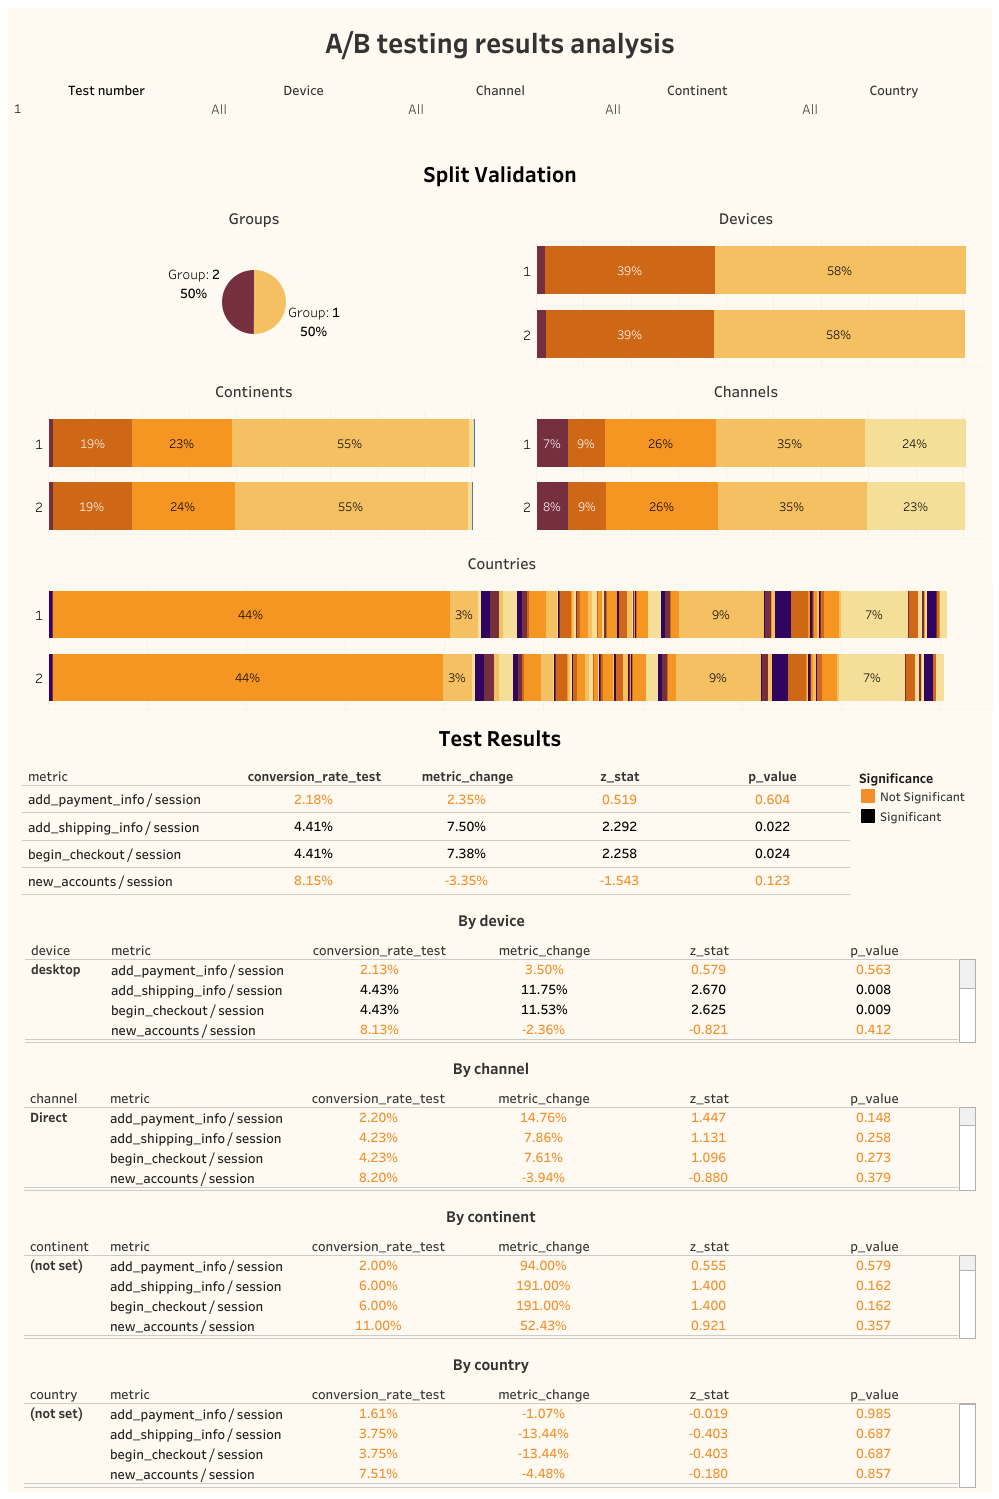